# From 1,000 Companies to an Investment Shortlist

## A Matplotlib-based business reporting notebook

You are a financial analyst. Your task is to transform a raw universe of listed companies into a short, defensible investment watchlist.

This notebook is designed for a data analytics class. It does not try to produce professional investment advice. Instead, it shows how charts help analysts answer business questions, communicate evidence, and progressively improve a visualization.

The central question is:

> **Which companies deserve further investment analysis, and why?**

We will use several chart types:

- Histogram
- Bar chart
- Boxplot
- Scatter plot
- Bubble chart
- Treemap chart
- Line chart
- Final score chart

For each major section, we follow the same reporting logic:

1. Define a business question.
2. Build a first simple chart.
3. Improve the chart with labels, colors, annotations, sorting, reference lines, or better scaling.
4. Extract a business interpretation.

In [163]:
# ============================================================
# 1. Import libraries
# ============================================================

# pandas is used for data loading, cleaning, filtering and aggregation.
import pandas as pd

# numpy is useful for numerical operations and handling missing/infinite values.
import numpy as np

# matplotlib is the core visualization library used in this notebook.
import matplotlib.pyplot as plt

# matplotlib.ticker helps us format axis labels in a readable way.
from matplotlib.ticker import FuncFormatter

# pathlib helps us write file paths that work across operating systems.
from pathlib import Path

# Optional: make pandas display more columns when we inspect the dataset.
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# A small global setting: larger default figure size improves readability in class.
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = False

In [164]:
# ============================================================
# 2. Load the dataset
# ============================================================

# Load the dataset from the CSV file named "data/symbol_info_3-25.csv" into a pandas DataFrame.
df_raw = pd.read_csv("data/symbol_info_3-25.csv")

# Show the dataset shape: rows and columns.
print("Dataset shape:", df_raw.shape)

# Preview the first rows.
df_raw.head()

Dataset shape: (1000, 38)


,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,fifty_day_average,two_hundred_day_avg,beta,pe_trailing,pe_forward,price_to_sales,price_to_book,total_revenue,net_income,profit_margins,free_cashflow,debt_to_equity,return_on_assets,return_on_equity,revenue_growth,earnings_growth,last_annual_dividend,dividend_yield,payout_ratio,average_volume,short_ratio,exchange,exchange_short_name,country,is_etf,is_fund,is_actively_trading,timestamp
0,AAPL,Apple Inc.,Technology,Consumer Electronics,3278873821184,3321891913728,218.270004,214.100006,260.100006,164.080002,231.919006,228.354950,1.178,34.591125,26.265944,8.285006,49.182064,395760009216,96150003712,0.24295,93833871360,145.000000,0.22519,1.36520,0.040,0.101,1.00,0.46,0.1571,52181373,2.71,NMS,NMS,United States,0,0,1,2025-03-22 04:50:05
1,MSFT,Microsoft Corporation,Technology,Software - Infrastructure,2908619014144,2939973795840,391.260010,386.839996,468.350006,376.910004,408.945801,423.364349,0.914,31.553228,26.171238,11.109996,9.610435,261802000384,92749996032,0.35428,51958124544,33.998001,0.14649,0.34291,0.123,0.102,3.32,0.85,0.2482,22370941,2.68,NMS,NMS,United States,0,0,1,2025-03-22 04:50:07
2,NVDA,NVIDIA Corporation,Technology,Semiconductors,2892136185856,2838940090368,117.699997,118.529999,153.130005,75.606003,126.937798,127.763115,1.765,40.034012,28.567961,22.162472,36.315952,130497003520,72879996928,0.55848,44169748480,12.946000,0.57417,1.19177,0.779,0.836,0.04,0.03,0.0116,271988186,0.84,NMS,NMS,United States,0,0,1,2025-03-22 04:50:06
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,Internet Retail,2079374704640,2133579530240,196.210007,194.949997,242.520004,151.610001,218.631393,199.768295,1.192,35.481014,31.904066,3.259417,7.268114,637959012352,59248001024,0.09287,44635873280,54.341999,0.07438,0.24290,0.105,0.846,0.00,0.00,0.0000,38226331,1.78,NMS,NMS,United States,0,0,1,2025-03-22 04:50:08
4,GOOGL,Alphabet Inc.,Communication Services,Internet Content & Information,1996906430464,1931518148608,163.990005,162.800003,207.050003,147.220001,182.666000,175.225204,1.025,20.396767,18.302456,5.705153,6.159943,350018011136,100118003712,0.28604,56580751360,8.655000,0.16740,0.32908,0.118,0.309,0.80,0.49,0.0746,29147868,2.01,NMS,NMS,United States,0,0,1,2025-03-22 04:50:09


In [165]:
# ============================================================
# 3. Inspect columns and missing values
# ============================================================

# A real analyst should never start plotting before understanding the data.
# Here we inspect column names, data types and missing values.

summary = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": df_raw.dtypes.astype(str).values,
    "missing_values": df_raw.isna().sum().values,
    "missing_pct": (df_raw.isna().mean().values * 100).round(2)
})

summary

,column,dtype,missing_values,missing_pct
0,symbol,str,0,0.0
1,company_name,str,0,0.0
2,sector,str,2,0.2
3,industry,str,2,0.2
4,market_cap,int64,0,0.0
5,enterprise_value,uint64,0,0.0
6,current_price,float64,0,0.0
7,previous_close,float64,0,0.0
8,fifty_two_week_high,float64,0,0.0
9,fifty_two_week_low,float64,0,0.0


## Data preparation

The raw dataset contains companies, ETFs, funds, active and inactive securities, and several financial indicators.

For this lesson, we restrict the analysis to active operating companies. This is not the only possible choice, but it makes the business story cleaner.

We also create readable columns expressed in billions of dollars or percentages. This improves chart readability and avoids large unreadable axis values.

In [166]:
# ============================================================
# 4. Clean the investment universe
# ============================================================

# Start from the raw dataset (independent copy)
df = df_raw.copy()

# Keep active operating companies only.
# is_etf == 0 removes ETFs.
# is_fund == 0 removes funds.
# is_actively_trading == 1 keeps securities that are currently trading.
# Positive market cap and revenue avoid invalid or non-meaningful ratios.
df = df[
    (df["is_etf"] == 0) &
    (df["is_fund"] == 0) &
    (df["is_actively_trading"] == 1) &
    (df["market_cap"] > 0) &
    (df["total_revenue"] > 0)
].copy()

# Convert large dollar values into billions.
# This makes charts much easier to read.
df["market_cap_b"] = df["market_cap"] / 1e9 
df["enterprise_value_b"] = df["enterprise_value"] / 1e9
df["revenue_b"] = df["total_revenue"] / 1e9
df["net_income_b"] = df["net_income"] / 1e9
df["free_cashflow_b"] = df["free_cashflow"] / 1e9

# Convert decimal ratios into percentages where appropriate.
# Example: 0.24 becomes 24%.
df["profit_margin_pct"] = df["profit_margins"] * 100
df["revenue_growth_pct"] = df["revenue_growth"] * 100
df["earnings_growth_pct"] = df["earnings_growth"] * 100
df["return_on_assets_pct"] = df["return_on_assets"] * 100
df["return_on_equity_pct"] = df["return_on_equity"] * 100

# The dividend_yield column in this dataset is already expressed like 0.46, 0.85, etc.
# We keep a separate column with a clear name.
df["dividend_yield_pct"] = df["dividend_yield"]

# Replace infinite values with missing values.
# Infinite values may appear after divisions or dirty data imports.
df = df.replace([np.inf, -np.inf], np.nan)

print("Cleaned investment universe:", df.shape)
df[["symbol", "company_name", "sector", "market_cap_b", "revenue_b", "profit_margin_pct", "beta"]].head()

Cleaned investment universe: (993, 49)


,symbol,company_name,sector,market_cap_b,revenue_b,profit_margin_pct,beta
0,AAPL,Apple Inc.,Technology,3278.873821,395.760009,24.295001,1.178
1,MSFT,Microsoft Corporation,Technology,2908.619014,261.802000,35.428002,0.914
2,NVDA,NVIDIA Corporation,Technology,2892.136186,130.497004,55.848002,1.765
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,2079.374705,637.959012,9.287000,1.192
4,GOOGL,Alphabet Inc.,Communication Services,1996.906430,350.018011,28.604001,1.025


In [167]:
# ============================================================
# 5. Helper functions for cleaner charts
# ============================================================

# Reusable formatter: show numbers as billions with one decimal.
def billions_formatter(x, pos):
    return f"{x:,.0f}B"

# Reusable formatter: show percentages with no decimal places.
def pct_formatter(x, pos):
    return f"{x:.0f}%"

# Reusable helper to remove unnecessary chart borders.
# This gives a cleaner report-style chart.
def clean_spines(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

# Reusable helper to annotate bars in a horizontal bar chart.
def annotate_hbar(ax, fmt="{:.1f}"):
    for patch in ax.patches:
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(width, y, "  " + fmt.format(width), va="center", fontsize=9)

# Business Question 1

## How concentrated is the market?

Before selecting companies, we need to understand the shape of the investment universe.

A common financial dataset is highly skewed: a small number of mega-cap companies dominate the total market capitalization, while most companies are much smaller.

The histogram helps answer:

> **Are most companies similar in size, or do a few giants dominate the universe?**

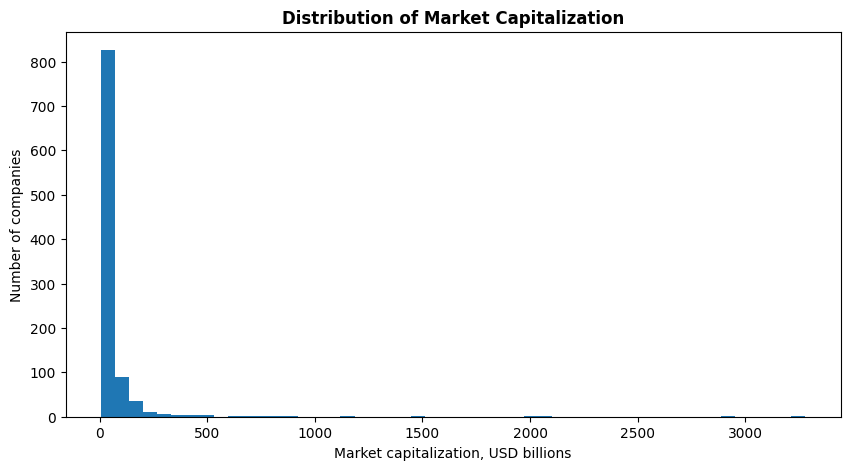

In [168]:
# ============================================================
# 6. Histogram, first version
# ============================================================

# A histogram shows the distribution of one numerical variable.
# Here we start with a basic histogram of market capitalization.

plt.figure(figsize=(10, 5))
plt.hist(df["market_cap_b"].dropna(), bins=50)
plt.title("Distribution of Market Capitalization")
plt.xlabel("Market capitalization, USD billions")
plt.ylabel("Number of companies")
plt.show()

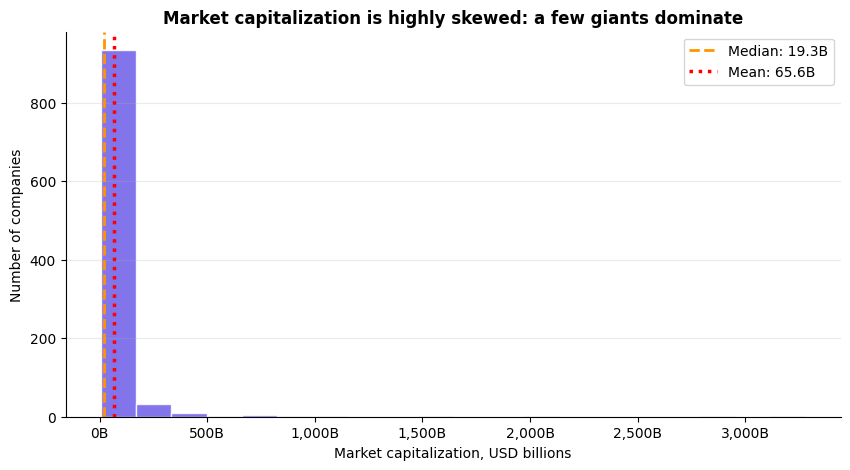

In [169]:
# ============================================================
# 7. Histogram, improved version
# ============================================================

# The first chart works, but it hides the main message.
# Market cap is usually extremely skewed, so we add:
# - a median line
# - a mean line
# - clearer colors
# - grid lines on the y-axis
# - a more interpretive title

market_cap = df["market_cap_b"].dropna()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(

    market_cap,          # Data to plot: one numerical value per company.
                         # In this case, market_cap contains the market capitalization values.

    bins=20,             # Number of intervals used to split the data.
                         # More bins = more detail, but the chart may become noisy.
                         # Fewer bins = smoother chart, but less detail.

    color="#6C5CE7",     # Fill color of the bars.
                         # Hexadecimal color code.
                         # This blue is visually clean and works well in business charts.

    edgecolor="white",   # Color of the border around each bar.
                         # White edges help separate adjacent bars visually.

    alpha=0.85           # Transparency level of the bars.
                         # 1.0 means fully opaque.
                         # 0.0 means fully transparent.
                         # 0.85 keeps the color strong but slightly softer.
)

median_value = market_cap.median()
mean_value = market_cap.mean()

ax.axvline(median_value, color="#FF9500", linestyle="--", linewidth=2, label=f"Median: {median_value:,.1f}B")
ax.axvline(mean_value, color="#FF0000", linestyle=":", linewidth=2.5, label=f"Mean: {mean_value:,.1f}B")

ax.set_title("Market capitalization is highly skewed: a few giants dominate")
ax.set_xlabel("Market capitalization, USD billions")
ax.set_ylabel("Number of companies")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.grid(axis="y", alpha=0.25)
ax.legend()
clean_spines(ax)

plt.show()

### Interpretation

If the mean is much larger than the median, the distribution is right-skewed. That means a few very large companies pull the average upward.

This matters because an investment universe can look diversified by number of companies, but still be economically dominated by a small group of mega-cap names.

# Business Question 2

## Which companies dominate the universe?

A histogram shows the distribution, but it does not identify the actual companies. For that, a sorted bar chart is more effective.

The bar chart answers:

> **Which companies have the largest market capitalization?**

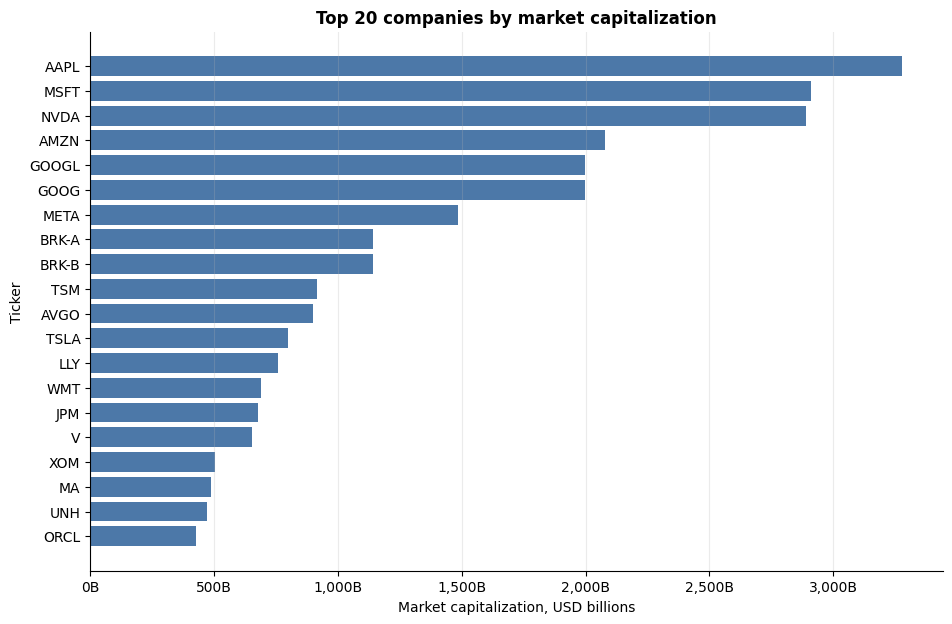

In [170]:
# ============================================================
# 8. Bar chart: top companies by market cap
# ============================================================

# Select the 20 largest companies by market capitalization.
top_market_cap = df.nlargest(20, "market_cap_b").copy()

# Sort ascending for a horizontal bar chart.
# This places the largest value at the top after inverting the y-axis.
top_market_cap = top_market_cap.sort_values("market_cap_b", ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(
    top_market_cap["symbol"],
    top_market_cap["market_cap_b"],
    color="#4C78A8"
)

ax.set_title("Top 20 companies by market capitalization")
ax.set_xlabel("Market capitalization, USD billions")
ax.set_ylabel("Ticker")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.grid(axis="x", alpha=0.25)
clean_spines(ax)

plt.show()

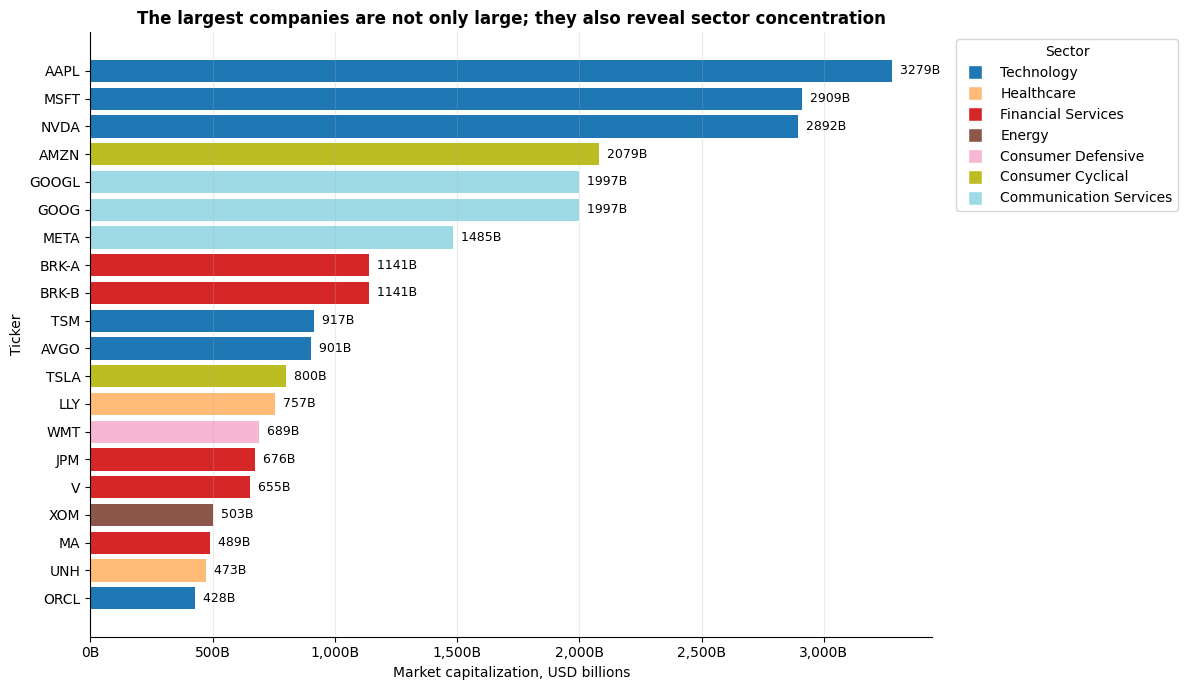

In [171]:
# ============================================================
# 9. Bar chart with sector colors and labels
# ============================================================

# A second version adds categorical color.
# Here, color represents sector.
# This helps students see whether the largest companies are concentrated in one area.

top_market_cap = df.nlargest(20, "market_cap_b").copy()
top_market_cap = top_market_cap.sort_values("market_cap_b", ascending=True)

# Create a color map for sectors.
# Each sector receives a color from the tab20 palette.
sectors = top_market_cap["sector"].fillna("Unknown").unique()
palette = plt.cm.tab20(np.linspace(0, 1, len(sectors)))
sector_to_color = dict(zip(sectors, palette))
colors = top_market_cap["sector"].fillna("Unknown").map(sector_to_color)

fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(top_market_cap["symbol"], top_market_cap["market_cap_b"], color=colors)

ax.set_title("The largest companies are not only large; they also reveal sector concentration")
ax.set_xlabel("Market capitalization, USD billions")
ax.set_ylabel("Ticker")
# Format the X-axis tick labels using a custom function.
# In this case, billions_formatter converts large numbers
# into a more readable financial format, such as $500B or $1.2T.
# This changes only how the axis labels are displayed;
# it does not modify the underlying data.
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.grid(axis="x", alpha=0.25)
clean_spines(ax)

# Add data labels to the bars.
annotate_hbar(ax, fmt="{:.0f}B")

# Create a custom legend.
legend_handles = [
    plt.Line2D([0], [0], marker="s", color="w", label=sector, markerfacecolor=color, markersize=10)
    for sector, color in sector_to_color.items()
]
ax.legend(handles=legend_handles, title="Sector", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

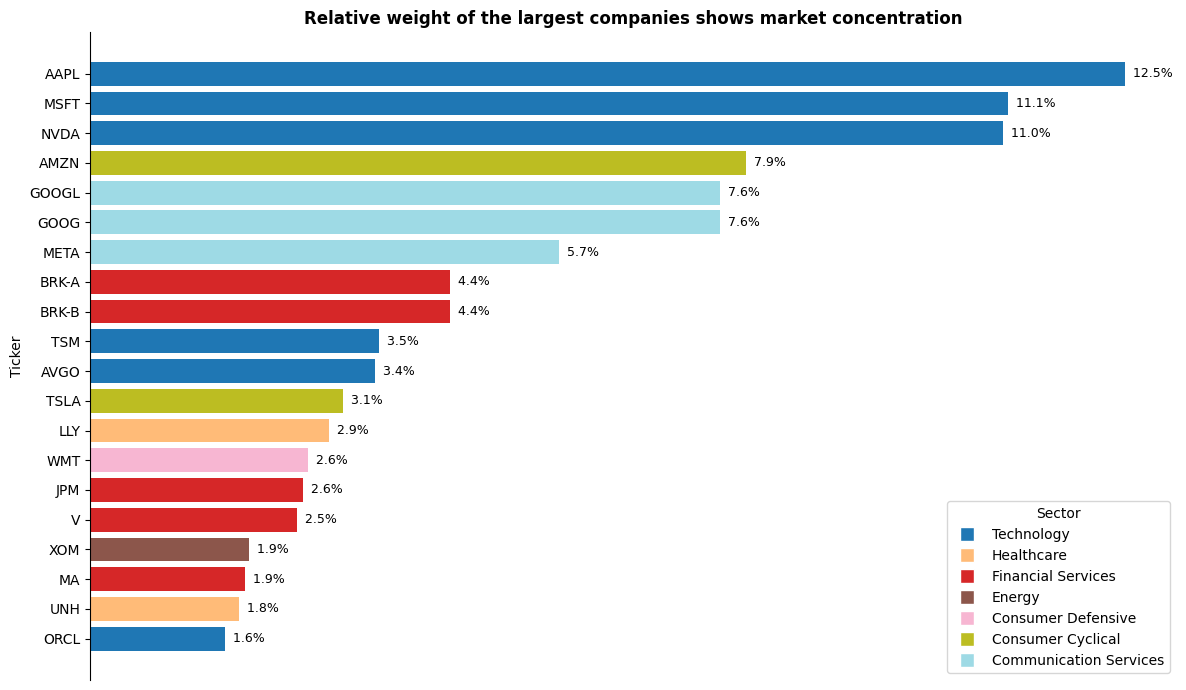

In [172]:
# ============================================================
# 9. Bar chart with sector colors and percentage labels
# ============================================================
# Select the 20 companies with the largest market capitalization.
top_market_cap = df.nlargest(20, "market_cap_b").copy()

# Calculate each company's weight as a percentage of the total market cap
# of the selected Top 20 companies.
#
# Example:
# If Apple has 3,000B market cap and the Top 20 total is 20,000B,
# Apple's percentage will be:
# 3,000 / 20,000 * 100 = 15%

top_market_cap["market_cap_pct"] = (
    top_market_cap["market_cap_b"] / top_market_cap["market_cap_b"].sum() * 100
)

# Sort ascending so the largest bar appears at the top in a horizontal bar chart.
top_market_cap = top_market_cap.sort_values("market_cap_pct", ascending=True)

# Create a color map for sectors.
# Each sector receives a color from the tab20 palette.
sectors = top_market_cap["sector"].fillna("Unknown").unique()
palette = plt.cm.tab20(np.linspace(0, 1, len(sectors)))
sector_to_color = dict(zip(sectors, palette))
colors = top_market_cap["sector"].fillna("Unknown").map(sector_to_color)
fig, ax = plt.subplots(figsize=(12, 7))

# Use the percentage column instead of the market cap in billions.
ax.barh(
    top_market_cap["symbol"],
    top_market_cap["market_cap_pct"],
    color=colors
)

ax.set_title("Relative weight of the largest companies shows market concentration")

# Remove the X-axis label because values are shown directly on the bars.
ax.set_xlabel("")
ax.set_ylabel("Ticker")

# Remove the vertical grid lines.
# The original version used:
# ax.grid(axis="x", alpha=0.25)
# We remove it because the percentage labels on the bars are enough.
ax.grid(False)

# Remove X-axis ticks and tick labels.
# This makes the chart cleaner and more report-like.
ax.tick_params(
    axis="x",
    which="both",
    bottom=False,
    top=False,
    labelbottom=False
)

# Optional: remove the X-axis spine as well.
# This removes the horizontal axis line at the bottom.
ax.spines["bottom"].set_visible(False)

# Keep  custom function to clean the other spines.
clean_spines(ax)

# Add percentage labels to the bars.
# This replaces the previous format "{:.0f}B".
annotate_hbar(ax, fmt="{:.1f}%")

# Create a custom legend.
# We build the legend manually because the bar colors were assigned
# from the sector_to_color dictionary, not automatically by Matplotlib.

legend_handles = [
    plt.Line2D(
        [0], [0],                # Dummy line coordinates.
                                # We do not want to draw an actual line;
                                # we only need an object for the legend.
        marker="s",              # Use a square marker to represent each sector color.
        color="w",               # Make the line itself white/invisible.
        label=sector,            # Text displayed in the legend for this sector.
        markerfacecolor=color,   # Fill the square marker with the sector color.
        markersize=10            # Size of the square marker in the legend.
    )
    for sector, color in sector_to_color.items()
]

# Place the legend inside the chart, in the lower-right corner.
# loc="lower right" anchors the legend box to the lower-right area of the axes.
#

# This is different from the previous version:
# bbox_to_anchor=(1.02, 1), loc="upper left"
# which placed the legend outside the plot area, to the right of the chart.
ax.legend(
    handles=legend_handles,
    title="Sector",
    loc="lower right"
)

plt.tight_layout()

plt.show()

# Business Question 3

## Which sectors dominate by number of companies and by market value?

A sector may contain many companies but represent a small share of total market capitalization. Another sector may contain fewer companies but dominate the market economically.

We therefore compare two views:

1. Number of companies by sector.
2. Total market capitalization by sector.

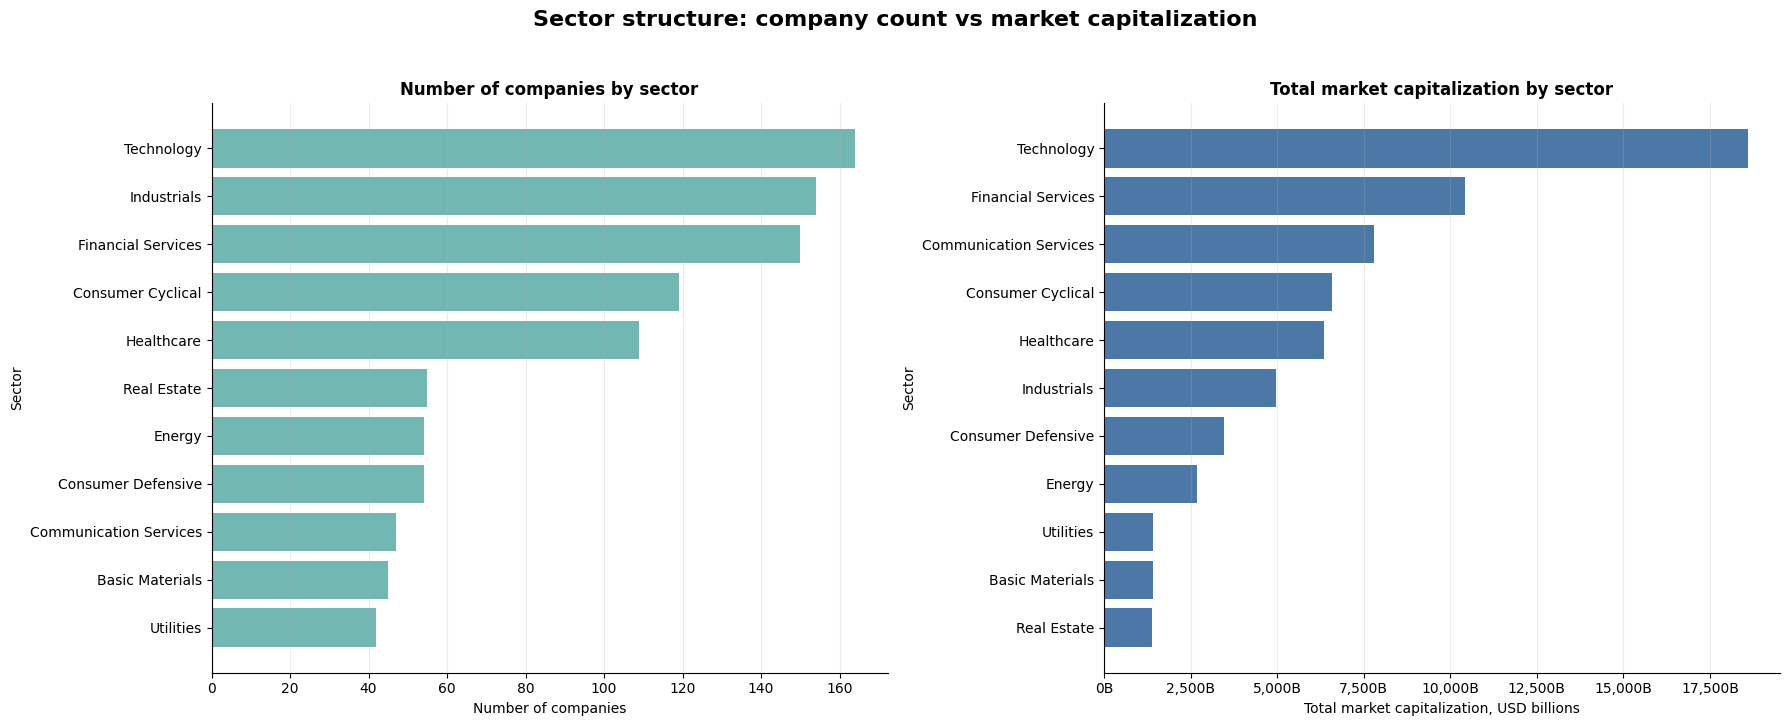

In [173]:
# ============================================================
# 10. Sector overview: count vs economic weight
# ============================================================

# This chart combines two complementary views:
#
# 1. How many companies are in each sector?
# 2. How much total market capitalization does each sector represent?
#

# Missing sector values are replaced with "Unknown".
sector_count = (
    df["sector"]
    .fillna("Unknown")
    .value_counts()
    .sort_values(ascending=True)
)

# Calculate the total market capitalization for each sector.
# Again, missing sector values are replaced with "Unknown".

sector_cap = (
    df
    .assign(sector_clean=df["sector"].fillna("Unknown"))
    .groupby("sector_clean")["market_cap_b"]
    .sum()
    .sort_values(ascending=True)
)

# Create one figure with two charts side by side:
# 1 row, 2 columns.
#
# sharey=False means each subplot keeps its own Y-axis labels.
# This is useful because the two rankings may have different orders.

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(18, 7),
    sharey=False
)

# Give meaningful names to the two axes.
ax_count = axes[0]
ax_cap = axes[1]

# ------------------------------------------------------------
# Left chart: number of companies by sector
# ------------------------------------------------------------

ax_count.barh(
    sector_count.index,          # Sector names on the Y-axis.
    sector_count.values,         # Number of companies on the X-axis.
    color="#72B7B2"              # Bar color.
)

ax_count.set_title("Number of companies by sector")
ax_count.set_xlabel("Number of companies")
ax_count.set_ylabel("Sector")

# Add vertical grid lines to make the bar lengths easier to compare.
ax_count.grid(axis="x", alpha=0.25)

# Clean unnecessary chart borders.
clean_spines(ax_count)

# ------------------------------------------------------------
# Right chart: total market capitalization by sector
# ------------------------------------------------------------

ax_cap.barh(
    sector_cap.index,            # Sector names on the Y-axis.
    sector_cap.values,           # Total sector market cap in USD billions.
    color="#4C78A8"              # Bar color.
)

ax_cap.set_title("Total market capitalization by sector")
ax_cap.set_xlabel("Total market capitalization, USD billions")
ax_cap.set_ylabel("Sector")

# Format large values on the X-axis.
# This makes the chart easier to read when values are very large.
ax_cap.xaxis.set_major_formatter(FuncFormatter(billions_formatter))

# Add vertical grid lines to help compare sector sizes.
ax_cap.grid(axis="x", alpha=0.25)

# Clean unnecessary chart borders.
clean_spines(ax_cap)

# Add a single title for the whole figure.
# y=1.03 moves the title slightly above the two charts.

fig.suptitle(
    "Sector structure: company count vs market capitalization",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

# Adjust spacing between the two charts.
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

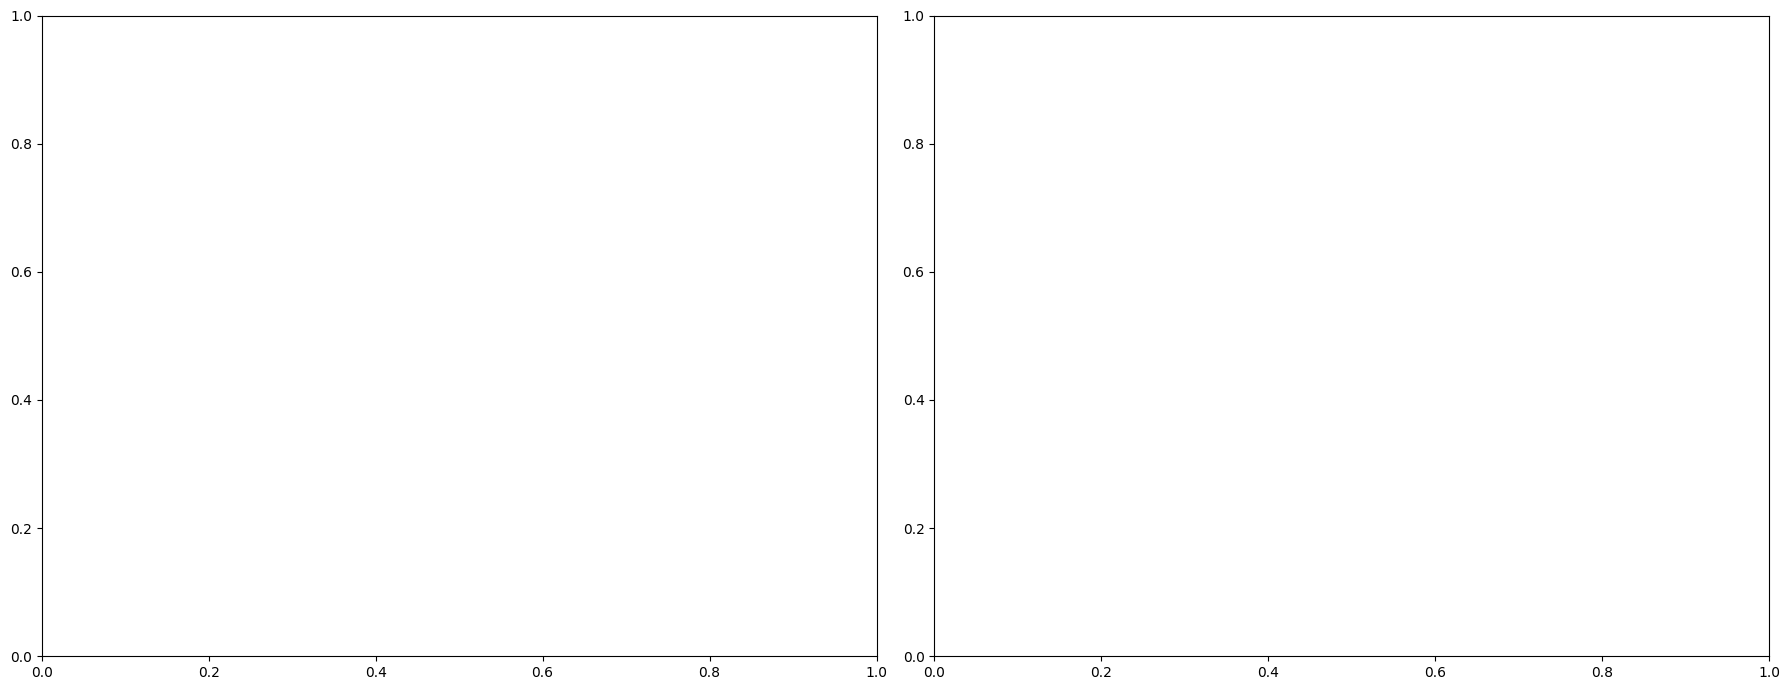

In [ ]:
# just one Sector Tech


sector_tech = df[df["sector"] == 'Technology']


sorted_tech = sector_tech.sort_values("market_cap_b", ascending = True)

sorted_tech = sorted_tech.tail(15)

# The graph

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(
    sorted_tech["symbol"],
    sorted_tech["market_cap_b"],
    color="#4C78A8"
)

ax.set_title("Top 15 Technology Companies by Market Capitalization")
ax.set_xlabel("Market Capitalization (Billions USD)")
ax.set_ylabel("Company Symbol")
ax.grid(axis="x", alpha=0.25)
clean_spines(ax)

plt.tight_layout()
plt.show()




# ------------------------------------------------------------
# Right chart: total market capitalization by sector
# ------------------------------------------------------------




sector_cap = (
    df
    .assign(sector_clean=df["sector"].fillna("Unknown"))
    .groupby("sector_clean")["market_cap_b"]
    .sum()
    .sort_values(ascending=True)
)


fig, ax_cap = plt.subplots(figsize=(11, 7))

ax_cap.barh(
    sector_cap.index,            # Sector names on the Y-axis.
    sector_cap.values,           # Total sector market cap in USD billions.
    color="#4C78A8"              # Bar color.
)

ax_cap.set_title("Total market capitalization by sector")
ax_cap.set_xlabel("Total market capitalization, USD billions")
ax_cap.set_ylabel("Sector")

# Format large values on the X-axis.
# This makes the chart easier to read when values are very large.
ax_cap.xaxis.set_major_formatter(FuncFormatter(billions_formatter))

# Add vertical grid lines to help compare sector sizes.
ax_cap.grid(axis="x", alpha=0.25)

# Clean unnecessary chart borders.
clean_spines(ax_cap)

# Add a single title for the whole figure.
# y=1.03 moves the title slightly above the two charts.

fig.suptitle(
    "Sector structure: company count vs market capitalization",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

fig, (ax, ax_cap) =plt.subplot(1, 2, figsize=(18, 7))

# Adjust spacing between the two charts.
plt.tight_layout()
plt.show()



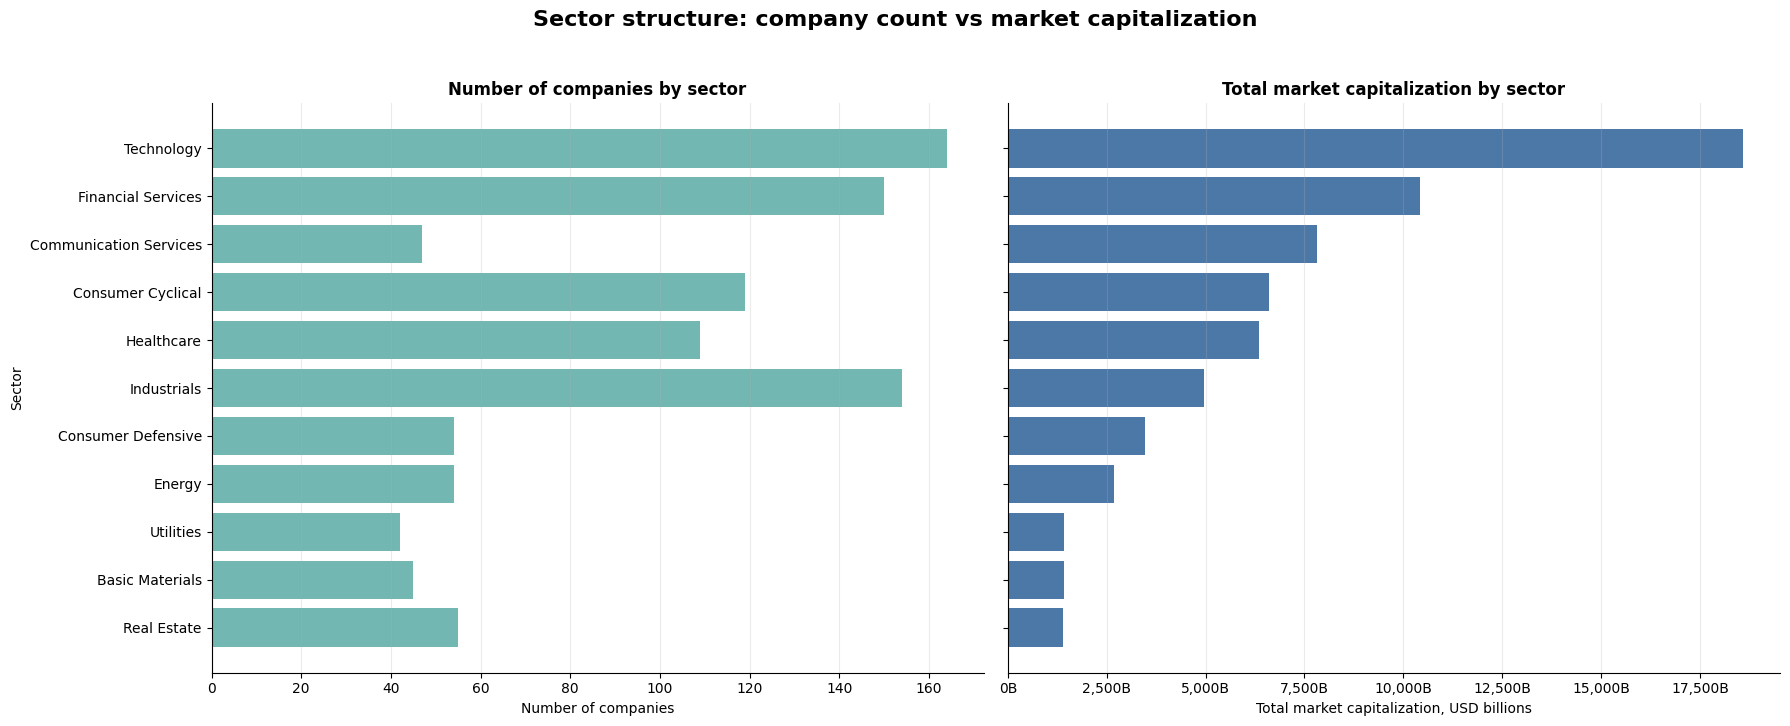

In [ ]:
# ============================================================
# 11. Sector overview with aligned sector order
# ============================================================

# Create a clean sector column.
df_sector = df.copy()
df_sector["sector_clean"] = df_sector["sector"].fillna("Unknown")

# Aggregate both metrics in one summary table.
sector_summary = (
    df_sector
    .groupby("sector_clean")
    .agg(
        company_count=("symbol", "count"),
        total_market_cap_b=("market_cap_b", "sum")
    )
    .sort_values("total_market_cap_b", ascending=True)
)

# Create one figure with two columns.
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(18, 7),
    sharey=True
)

ax_count = axes[0]
ax_cap = axes[1]

# Left chart: company count.
ax_count.barh(
    sector_summary.index,
    sector_summary["company_count"],
    color="#72B7B2"
)

ax_count.set_title("Number of companies by sector")
ax_count.set_xlabel("Number of companies")
ax_count.set_ylabel("Sector")
ax_count.grid(axis="x", alpha=0.25)
clean_spines(ax_count)

# Right chart: total market capitalization.
ax_cap.barh(
    sector_summary.index,
    sector_summary["total_market_cap_b"],
    color="#4C78A8"
)

ax_cap.set_title("Total market capitalization by sector")
ax_cap.set_xlabel("Total market capitalization, USD billions")
ax_cap.set_ylabel("")

ax_cap.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax_cap.grid(axis="x", alpha=0.25)
clean_spines(ax_cap)

fig.suptitle(
    "Sector structure: company count vs market capitalization",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

### Teaching point

The two charts may tell different stories.

A sector can be large in terms of company count but small in total value. For investment analysis, economic weight is often more relevant than count.

# Business Question 4

## Which companies dominate the market visually?

So far, we have used bar charts to compare companies and sectors.

A bar chart is precise and easy to read, but it can become long when we want to compare many companies at once. A treemap gives us a more compact view of market composition.

In a treemap:

- each rectangle represents one company;
- the area of each rectangle is proportional to market capitalization;
- larger rectangles represent companies with larger market value;
- color can be used to represent sector.

This chart helps answer a simple business question:

> **Are the largest companies similar in size, or does a small group dominate the market?**

For this example, we use the `squarify` library. Matplotlib does not include a native treemap chart, so `squarify` calculates the rectangle layout and Matplotlib renders the final visualization.

The goal is not to replace bar charts. The goal is to show that different charts answer different types of questions:

- use a bar chart when you need accurate ranking and comparison;
- use a treemap when you want to show composition, concentration, and relative size in a compact visual.

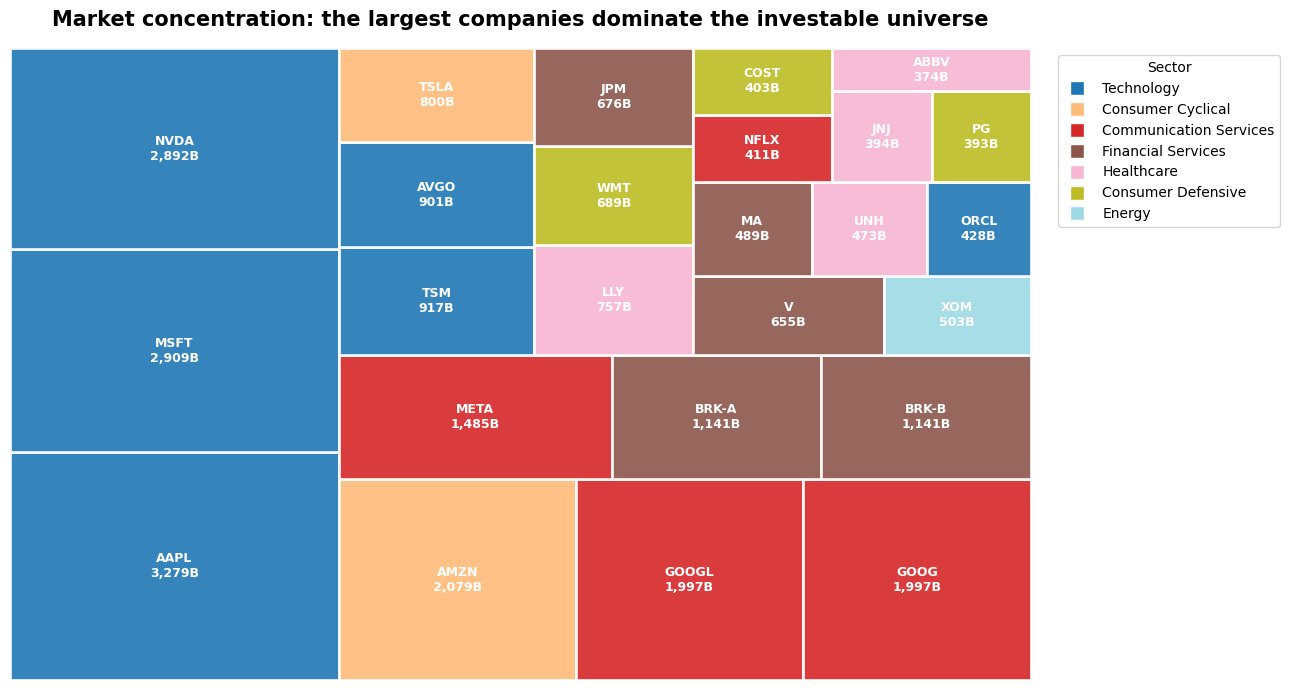

In [ ]:
# ============================================================
# 12. Treemap: which companies dominate the market?
# ============================================================

# Business question:
# Are the largest companies similar in size,
# or does a small group dominate the market?
#
# A treemap is useful when we want to show composition.
# Each rectangle represents one company.
# The area of the rectangle is proportional to market capitalization.
#
# In this chart:
# - larger rectangle = larger market capitalization
# - color = sector
# - label = ticker and market capitalization

import squarify

# Select the 25 largest companies by market capitalization.
# We keep only 25 companies because treemaps become hard to read
# when there are too many small rectangles.
top25 = df.nlargest(25, "market_cap_b").copy()

# Sort from largest to smallest.
# This helps squarify place the largest rectangles more prominently.
top25 = top25.sort_values("market_cap_b", ascending=False)

# Replace missing sector values with "Unknown".
# This avoids problems when assigning colors.
top25["sector_clean"] = top25["sector"].fillna("Unknown")

# Create a color map for sectors.
# Each sector receives one color from the tab20 palette.
sectors = top25["sector_clean"].unique()
palette = plt.cm.tab20(np.linspace(0, 1, len(sectors)))
sector_to_color = dict(zip(sectors, palette))

# Assign one color to each company based on its sector.
colors = top25["sector_clean"].map(sector_to_color)

# Create labels for the rectangles.
# Each label shows:
# - the company ticker
# - the market capitalization in USD billions
labels = [
    f"{symbol}\n{market_cap:,.0f}B"
    for symbol, market_cap in zip(top25["symbol"], top25["market_cap_b"])
]

fig, ax = plt.subplots(figsize=(13, 7))

# Draw the treemap.
# sizes controls the area of each rectangle.
# label controls the text displayed inside each rectangle.
# color controls the rectangle colors.
# alpha controls transparency.
squarify.plot(
    sizes=top25["market_cap_b"],
    label=labels,
    color=colors,
    alpha=0.9,
    edgecolor="white",
    linewidth=2,
    text_kwargs={
        "fontsize": 9,
        "color": "white",
        "weight": "bold"
    },
    ax=ax
)

# Add a clear, business-oriented title.
ax.set_title(
    "Market concentration: the largest companies dominate the investable universe",
    fontsize=15,
    fontweight="bold",
    pad=16
)

# Remove axes because a treemap does not need X and Y coordinates.
# The position of each rectangle is not meaningful.
# Only the area is meaningful.
ax.axis("off")

# Create a custom legend for sectors.
# We build it manually because the colors were assigned from a dictionary.
legend_handles = [
    plt.Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        label=sector,
        markerfacecolor=color,
        markersize=10
    )
    for sector, color in sector_to_color.items()
]

# Place the legend outside the chart on the right.
# This keeps the treemap area clean.
ax.legend(
    handles=legend_handles,
    title="Sector",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()